# Assignment 3: Deep Q-Learning


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from copy import deepcopy
import gymnasium
import random

# 1. Define the parameters

In [ ]:
# Discount factor
GAMMA = 0.95

# Batch size
BATCH_SIZE = 64
# Capacity of the replay buffer
BUFFER_CAPACITY = 5000
# Update target net every ... episodes
UPDATE_TARGET_EVERY = 50

# Initial value of epsilon
EPSILON_START = 1.0
# Parameter to decrease epsilon
DECREASE_EPSILON = 400
# Minimum value of epislon
EPSILON_MIN = 0.05

# Number of training episodes
N_EPISODES = 800

# Learning rate
LEARNING_RATE = 1e-3

# Max rollout length
ROLLOUT_LENGTH = 120

# 2. Define the environment

You will need to change this!

In [ ]:
class Environment:
    """
    Windy Battery Crystal Collector (stochastic, resource-limited).
    Tiles:
      A = agent
      C = crystal (common)
      R = crystal (rare)
      F = fire (moving hazard)
      W = wall (impassable)
      B = battery charger
      E = exit (terminal only after all crystals collected)
      - = empty
    Actions (numActions=5):
      0 left, 1 right, 2 up, 3 down, 4 wait
    Observation:
      5x5 one-hot window centered on agent over tile types + 2 scalars:
        [battery_norm, remaining_crystals_ratio]
    """
    def __init__(self, map,
                 slip_prob=0.12,
                 fire_move_prob=0.35,
                 max_battery=30,
                 step_cost=-1,
                 wall_penalty=-2,
                 crystal_reward=+8,
                 rare_reward=+15,
                 charge_reward=+2,
                 fire_penalty=-200,
                 battery_death_penalty=-200,
                 exit_success_reward=+250,
                 exit_early_penalty=-20):
        self.map = map
        self.initialMap = deepcopy(map)

        # Dynamics
        self.slip_prob = slip_prob
        self.fire_move_prob = fire_move_prob

        # Battery
        self.max_battery = max_battery
        self.battery = max_battery

        # Rewards
        self.step_cost = step_cost
        self.wall_penalty = wall_penalty
        self.crystal_reward = crystal_reward
        self.rare_reward = rare_reward
        self.charge_reward = charge_reward
        self.fire_penalty = fire_penalty
        self.battery_death_penalty = battery_death_penalty
        self.exit_success_reward = exit_success_reward
        self.exit_early_penalty = exit_early_penalty

        # State bookkeeping
        self.totalCrystals = 0
        self.remainingCrystals = 0
        self.playerPos = None
        self.firePositions = []

        # Observation spec
        self.values = ["A","C","R","F","W","B","E","-"]
        self.window = 5
        self.observationSize = self.window*self.window*len(self.values) + 2  # +2 scalars
        self.defaultToken = "-"
        self.playerToken = "A"
        self.numActions = 5  # includes WAIT

        self.reset()

    def reset(self):
        self.map = deepcopy(self.initialMap)
        self.totalCrystals = 0
        self.remainingCrystals = 0
        self.playerPos = None
        self.firePositions = []
        self.battery = self.max_battery

        for x in range(len(self.map)):
            for y in range(len(self.map[0])):
                t = self.map[x][y]
                if t == "A":
                    self.playerPos = [x,y]
                elif t in ("C","R"):
                    self.totalCrystals += 1
                elif t == "F":
                    self.firePositions.append([x,y])

        self.remainingCrystals = self.totalCrystals
        return self.observation()

    def _in_bounds(self, x, y):
        return 0 <= x < len(self.map) and 0 <= y < len(self.map[0])

    def _is_blocked(self, x, y):
        return (not self._in_bounds(x,y)) or (self.map[x][y] == "W")

    def observation(self):
        cx, cy = self.playerPos
        k = self.window // 2
        obs = []

        for x in range(cx-k, cx+k+1):
            for y in range(cy-k, cy+k+1):
                oneHot = [0]*len(self.values)
                if self._in_bounds(x,y):
                    tile = self.map[x][y]
                    oneHot[self.values.index(tile)] = 1
                # else: keep zeros for out-of-bounds
                obs.append(oneHot)

        flat = np.array(obs).flatten().astype(np.float32)

        battery_norm = np.array([self.battery / self.max_battery], dtype=np.float32)
        rem_ratio = np.array([0.0 if self.totalCrystals == 0 else self.remainingCrystals / self.totalCrystals], dtype=np.float32)

        return np.concatenate([flat, battery_norm, rem_ratio], axis=0)

    def observationStr(self):
        # 5x5 string view (useful for debug printing)
        cx, cy = self.playerPos
        k = self.window // 2
        s = ""
        for x in range(cx-k, cx+k+1):
            row = ""
            for y in range(cy-k, cy+k+1):
                if self._in_bounds(x,y):
                    row += self.map[x][y]
                else:
                    row += "X"
            s += row + "\n"
        return s.strip()

    def _maybe_slip(self, action):
        if random.random() < self.slip_prob:
            return random.randint(0, self.numActions-1)
        return action

    def _move_fire(self):
        # Each fire may move randomly into adjacent empty/cell with crystal/charger/exit
        # Fire does NOT move through walls.
        new_positions = []
        occupied = set((p[0],p[1]) for p in self.firePositions)

        for fx, fy in self.firePositions:
            if random.random() > self.fire_move_prob:
                new_positions.append([fx,fy])
                continue

            candidates = [(fx-1,fy),(fx+1,fy),(fx,fy-1),(fx,fy+1)]
            random.shuffle(candidates)

            moved = False
            for nx, ny in candidates:
                if self._is_blocked(nx,ny):
                    continue
                if (nx,ny) in occupied:
                    continue
                # allow fire to move onto empty/crystal/charger/exit (but not onto agent handled after)
                if self.map[nx][ny] != "W":
                    # clear old tile (if still F)
                    if self.map[fx][fy] == "F":
                        self.map[fx][fy] = self.defaultToken
                    self.map[nx][ny] = "F"
                    occupied.remove((fx,fy))
                    occupied.add((nx,ny))
                    new_positions.append([nx,ny])
                    moved = True
                    break
            if not moved:
                new_positions.append([fx,fy])

        self.firePositions = new_positions

    def step(self, action):
        reward = 0.0
        terminal = False

        # Battery drain each step (including wait)
        self.battery -= 1
        reward += self.step_cost

        if self.battery <= 0:
            return self.observation(), self.battery_death_penalty, True

        action = self._maybe_slip(action)

        oldx, oldy = self.playerPos
        nx, ny = oldx, oldy

        # Actions: 0 L,1 R,2 U,3 D,4 WAIT
        if action == 0: nx -= 1
        elif action == 1: nx += 1
        elif action == 2: ny -= 1
        elif action == 3: ny += 1
        elif action == 4: pass

        # Wall / bounds handling
        if self._is_blocked(nx, ny):
            reward += self.wall_penalty
            nx, ny = oldx, oldy  # stay put

        # Move agent on map (temporarily clear old position)
        self.map[oldx][oldy] = self.defaultToken

        # Interact with tile agent moves onto
        tile = self.map[nx][ny]

        # If tile is fire, die
        if tile == "F":
            self.playerPos = [nx, ny]
            self.map[nx][ny] = self.playerToken
            return self.observation(), self.fire_penalty, True

        # Collect crystal
        if tile == "C":
            self.remainingCrystals -= 1
            reward += self.crystal_reward
        elif tile == "R":
            self.remainingCrystals -= 1
            reward += self.rare_reward

        # Charge battery
        if tile == "B":
            self.battery = self.max_battery
            reward += self.charge_reward

        # Exit logic
        if tile == "E":
            if self.remainingCrystals == 0:
                reward += self.exit_success_reward
                terminal = True
            else:
                reward += self.exit_early_penalty

        # Place agent
        self.playerPos = [nx, ny]
        self.map[nx][ny] = self.playerToken

        # Move fire AFTER agent moves (stochastic dynamics)
        self._move_fire()

        # If fire moved onto agent, die
        ax, ay = self.playerPos
        if any((fx == ax and fy == ay) for fx, fy in self.firePositions):
            return self.observation(), self.fire_penalty, True

        return self.observation(), float(reward), terminal

In [ ]:
#Define Map (note this is essentially rotated -90 degrees from how it will "look" to the agent)
map = [
    ["W","W","W","W","W","W","W"],
    ["W","A","-","C","-","B","W"],
    ["W","-","W","-","W","-","W"],
    ["W","-","W","F","-","-","W"],
    ["W","-","-","-","W","R","W"],
    ["W","E","W","-","-","-","W"],
    ["W","W","W","W","W","W","W"],
]

In [ ]:
env = Environment(
    map,
    slip_prob=0.08,
    fire_move_prob=0.20,
    max_battery=45,
    step_cost=-1,
    wall_penalty=-2,
    crystal_reward=+5,
    rare_reward=+8,
    charge_reward=+2,
    fire_penalty=-50,
    battery_death_penalty=-50,
    exit_success_reward=+80,
    exit_early_penalty=-10
)

# 2. Define the replay buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.memory) < self.capacity:
            self.memory.append((state, action, reward, next_state, done))
        else:
            self.memory[self.position] = (state, action, reward, next_state, done)
            self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)


replay_buffer = ReplayBuffer(BUFFER_CAPACITY)

# 3. Define the neural network architecture, objective and optimizer

You will need to change this!

In [ ]:
class Net(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
hidden_size = 128
obs_size = env.observationSize
n_actions = env.numActions

q_net = Net(obs_size, hidden_size, n_actions)
target_net = Net(obs_size, hidden_size, n_actions)
target_net.load_state_dict(q_net.state_dict())

# Huber loss (UPDATED)
objective = nn.SmoothL1Loss()

optimizer = optim.Adam(params=q_net.parameters(), lr=LEARNING_RATE)

# 4. Implement Deep Q-Learning

In [ ]:
train_losses = []
episode_returns = []
eval_returns = []
max_q_values = []

In [ ]:
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return random.randint(0, env.numActions - 1)
    else:
        with torch.no_grad():
            state_v = torch.FloatTensor(state).unsqueeze(0)
            q_values = q_net(state_v)
            return torch.argmax(q_values).item()

def eval_dqn(n_sim=1):
    env_copy = deepcopy(env)
    episode_rewards = np.zeros(n_sim)

    for ii in range(n_sim):
        state = env_copy.reset()
        done = False
        rolloutStep = 0
        while not done and rolloutStep <= ROLLOUT_LENGTH:
            action = choose_action(state, 0.0)
            next_state, reward, done = env_copy.step(action)
            episode_rewards[ii] += reward
            state = next_state
            rolloutStep += 1
    return episode_rewards

In [ ]:
def update(state, action, reward, next_state, done):
    replay_buffer.push(state, action, reward, next_state, done)

    if len(replay_buffer) < BATCH_SIZE:
        return None

    transitions = replay_buffer.sample(BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*transitions)

    states_v = torch.FloatTensor(states)
    actions_v = torch.LongTensor(actions).unsqueeze(-1)
    rewards_v = torch.FloatTensor(rewards).unsqueeze(-1)
    rewards_v = torch.clamp(rewards_v, -50, 50)
    next_states_v = torch.FloatTensor(next_states)
    dones_v = torch.BoolTensor(dones).unsqueeze(-1)

    q_values = q_net(states_v).gather(1, actions_v)

    with torch.no_grad():
        # Double DQN target
        next_actions = q_net(next_states_v).argmax(1).unsqueeze(-1)
        next_q_values = target_net(next_states_v).gather(1, next_actions)
        target_q_values = rewards_v + GAMMA * next_q_values * (~dones_v)

    loss = objective(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_net.parameters(), 1.0)  # gradient clipping
    optimizer.step()

    # Track metrics
    train_losses.append(loss.item())
    max_q_values.append(q_values.detach().max().item())

    return loss.item()

Train

In [ ]:
EVAL_EVERY = 5
REWARD_THRESHOLD = 1000

def train():
    state = env.reset()
    epsilon = EPSILON_START
    ep = 0
    rolloutStep = 0
    episode_reward = 0

    while ep < N_EPISODES:
        action = choose_action(state, epsilon)
        next_state, reward, done = env.step(action)

        _ = update(state, action, reward, next_state, done)

        episode_reward += reward
        state = next_state
        rolloutStep += 1

        if done or rolloutStep >= ROLLOUT_LENGTH:
            episode_returns.append(episode_reward)

            state = env.reset()
            rolloutStep = 0
            episode_reward = 0
            ep += 1

            if ep % EVAL_EVERY == 0:
                rewards = eval_dqn(20)
                mean_eval = float(np.mean(rewards))
                eval_returns.append(mean_eval)
                print(f"Episode {ep}, Eval Reward: {mean_eval:.2f}")

                if mean_eval >= REWARD_THRESHOLD:
                    break

            if ep % UPDATE_TARGET_EVERY == 0:
                target_net.load_state_dict(q_net.state_dict())

            epsilon = EPSILON_MIN + (EPSILON_START - EPSILON_MIN) * \
                      np.exp(-1.0 * ep / DECREASE_EPSILON)

In [ ]:
train()

Episode 5, Eval Reward: -95.00
Episode 10, Eval Reward: -78.05
Episode 15, Eval Reward: -85.45
Episode 20, Eval Reward: -92.35
Episode 25, Eval Reward: -95.10
Episode 30, Eval Reward: -91.70
Episode 35, Eval Reward: -93.00
Episode 40, Eval Reward: -96.30
Episode 45, Eval Reward: -94.10
Episode 50, Eval Reward: -88.00
Episode 55, Eval Reward: -79.50
Episode 60, Eval Reward: -85.05
Episode 65, Eval Reward: -79.85
Episode 70, Eval Reward: -82.60
Episode 75, Eval Reward: -72.55
Episode 80, Eval Reward: -83.95
Episode 85, Eval Reward: -80.40
Episode 90, Eval Reward: -86.55
Episode 95, Eval Reward: -87.05
Episode 100, Eval Reward: -85.15
Episode 105, Eval Reward: -87.10
Episode 110, Eval Reward: -96.95
Episode 115, Eval Reward: -87.35
Episode 120, Eval Reward: -80.65
Episode 125, Eval Reward: -82.60
Episode 130, Eval Reward: -78.80
Episode 135, Eval Reward: -82.55
Episode 140, Eval Reward: -78.10
Episode 145, Eval Reward: -78.40
Episode 150, Eval Reward: -74.45
Episode 155, Eval Reward: -77.

In [ ]:
rewards = eval_dqn(20)
print("\nmean reward after training = ", np.mean(rewards))


mean reward after training =  -86.0


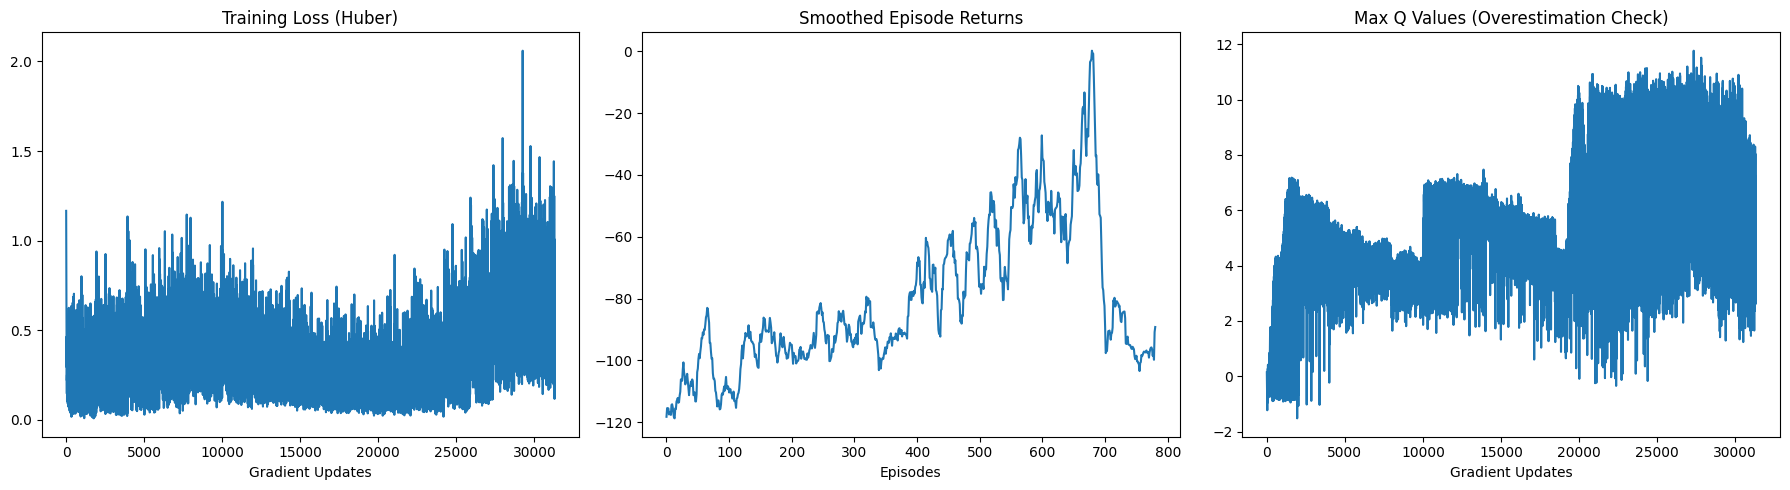

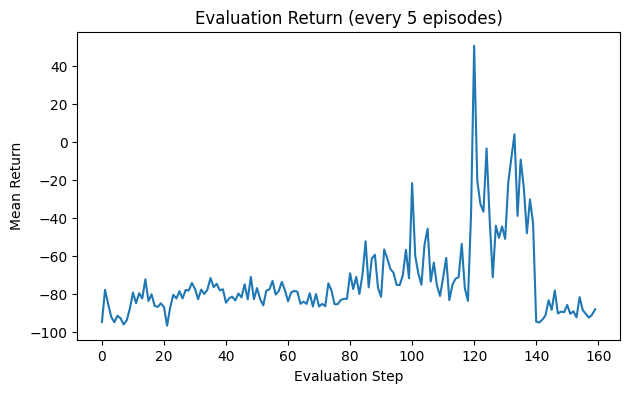

In [ ]:
import matplotlib.pyplot as plt

def moving_average(data, window=20):
    data = np.array(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode="valid")

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(train_losses)
plt.title("Training Loss (Huber)")
plt.xlabel("Gradient Updates")

plt.subplot(1,3,2)
plt.plot(moving_average(episode_returns))
plt.title("Smoothed Episode Returns")
plt.xlabel("Episodes")

plt.subplot(1,3,3)
plt.plot(max_q_values)
plt.title("Max Q Values (Overestimation Check)")
plt.xlabel("Gradient Updates")

plt.tight_layout()
plt.show()

if len(eval_returns) > 0:
    plt.figure(figsize=(7,4))
    plt.plot(eval_returns)
    plt.title("Evaluation Return (every 5 episodes)")
    plt.xlabel("Evaluation Step")
    plt.ylabel("Mean Return")
    plt.show()


# Run the DQN policy verbosely

In [ ]:
env_copy = deepcopy(env)
state = env_copy.reset()
done = False
rolloutStep = 0

while not done and rolloutStep <= ROLLOUT_LENGTH:
    action = choose_action(state, 0.0)
    next_state, reward, done = env_copy.step(action)
    state = next_state
    rolloutStep += 1
    print("Step :", rolloutStep)
    print("Action:", action)
    stringObservation = env_copy.observationStr()
    print("State:")
    print(env_copy.observationStr())
    print("Reward:", reward)

Step : 1
Action: 3
State:
XXXXX
XWWWW
XWA-C
XW-W-
XW-WF
Reward: -3.0
Step : 2
Action: 3
State:
XXXXX
WWWWW
W-AC-
W-W-W
W-WF-
Reward: -1.0
Step : 3
Action: 3
State:
XXXXX
WWWWW
--A-B
-W-W-
-WF--
Reward: 4.0
Step : 4
Action: 2
State:
XXXXX
WWWWW
W-A--
W-WFW
W-W--
Reward: -1.0
Step : 5
Action: 2
State:
XXXXX
XWWWW
XWA--
XW-WF
XW-W-
Reward: -1.0
Step : 6
Action: 1
State:
XWWWW
XW---
XWAWF
XW-W-
XW---
Reward: -1.0
Step : 7
Action: 1
State:
XW---
XW-WF
XWAW-
XW---
XWEW-
Reward: -1.0
Step : 8
Action: 1
State:
XW-WF
XW-W-
XWA--
XWEW-
XWWWW
Reward: -1.0
Step : 9
Action: 3
State:
W-WFW
W-W--
W-A-W
WEW--
WWWWW
Reward: -1.0
Step : 10
Action: 2
State:
W-WFW
W-W--
W-A-W
WEW--
WWWWW
Reward: -3.0
Step : 11
Action: 2
State:
XW-WF
XW-W-
XWA--
XWEW-
XWWWW
Reward: -1.0
Step : 12
Action: 3
State:
W-WFW
W-W--
W-A-W
WEW--
WWWWW
Reward: -1.0
Step : 13
Action: 2
State:
XW-WF
XW-W-
XWA--
XWEW-
XWWWW
Reward: -1.0
Step : 14
Action: 3
State:
W-W-W
W-W--
W-A-W
WEW--
WWWWW
Reward: -1.0
Step : 15
Action: 2
State:
XW-

Replay buffer size: 2000
State tensor shape: torch.Size([2000, 202])
Action tensor shape: torch.Size([2000])

Starting BC Training...
Epoch 0, Loss: 1.5692
Epoch 5, Loss: 1.3366
Epoch 10, Loss: 1.1216


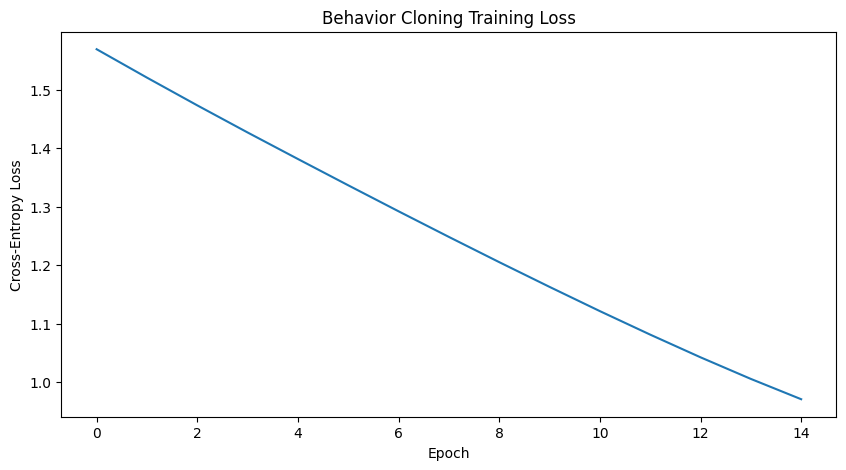

Behavior Cloning Training Accuracy: 74.35%

--- DQN Performance (Teacher) ---
mean_reward: -168.86
std_reward: 18.19
success_rate: 0.00
fire_death_rate: 1.00
battery_death_rate: 0.00

--- Behavior Cloning Performance (Student) ---
mean_reward: -162.72
std_reward: 38.00
success_rate: 0.00
fire_death_rate: 1.00
battery_death_rate: 0.00

Behavior Cloning Rollout Example:

Step 1: Action 3, Reward -1.0
Step 2: Action 3, Reward -3.0
Step 3: Action 3, Reward -3.0
Step 4: Action 3, Reward -3.0
Step 5: Action 3, Reward -3.0
Step 6: Action 3, Reward -3.0
Step 7: Action 3, Reward -3.0
Step 8: Action 3, Reward -3.0
Step 9: Action 3, Reward -3.0
Step 10: Action 3, Reward -3.0
Step 11: Action 3, Reward -3.0
Step 12: Action 3, Reward -3.0
Step 13: Action 3, Reward -3.0
Step 14: Action 3, Reward -3.0
Step 15: Action 3, Reward -3.0
Step 16: Action 3, Reward -1.0


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from copy import deepcopy


buffer_size = len(replay_buffer.memory)

if buffer_size == 0:
    print("Replay buffer is empty. Collecting data using the current policy...")


    temp_state = env.reset()
    for _ in range(2000):

        temp_action = choose_action(temp_state, epsilon=0.2)
        temp_next_state, temp_reward, temp_done = env.step(temp_action)


        replay_buffer.push(temp_state, temp_action, temp_reward, temp_next_state, temp_done)

        temp_state = temp_next_state
        if temp_done:
            temp_state = env.reset()

    print(f"Collected {len(replay_buffer.memory)} samples.")
else:
    print("Replay buffer size:", buffer_size)


states = []
actions = []

# Unpack the replay buffer
for (s, a, r, ns, d) in replay_buffer.memory:
    states.append(s)
    actions.append(a)

states = torch.FloatTensor(np.array(states))
actions = torch.LongTensor(np.array(actions))

print("State tensor shape:", states.shape)
print("Action tensor shape:", actions.shape)


bc_model = nn.Sequential(
    nn.Linear(env.observationSize, 128),
    nn.ReLU(),
    nn.Linear(128, env.numActions)
)

optimizer_bc = optim.Adam(bc_model.parameters(), lr=1e-3)
criterion_bc = nn.CrossEntropyLoss()


bc_losses = []

print("\nStarting BC Training...")
for epoch in range(15):
    # Forward pass
    logits = bc_model(states)
    loss = criterion_bc(logits, actions)

    # Backward pass
    optimizer_bc.zero_grad()
    loss.backward()
    optimizer_bc.step()

    bc_losses.append(loss.item())
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(bc_losses)
plt.title("Behavior Cloning Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.show()


with torch.no_grad():
    preds = bc_model(states).argmax(1)
    accuracy = (preds == actions).float().mean().item()

print(f"Behavior Cloning Training Accuracy: {accuracy:.2%}")


def choose_action_bc(state):
    with torch.no_grad():
        state_v = torch.FloatTensor(state).unsqueeze(0)
        logits = bc_model(state_v)
        return torch.argmax(logits).item()


def eval_dqn_detailed(n_sim=50):
    env_copy = deepcopy(env)
    rewards = []
    successes = 0
    fire_deaths = 0
    battery_deaths = 0

    for _ in range(n_sim):
        state = env_copy.reset()
        done = False
        total_reward = 0
        steps = 0
        last_reward = 0

        while not done and steps <= ROLLOUT_LENGTH:
            # Use DQN Policy (Greedy)
            action = choose_action(state, epsilon=0.0)
            state, reward, done = env_copy.step(action)
            total_reward += reward
            last_reward = reward
            steps += 1

        rewards.append(total_reward)

        if last_reward == env.exit_success_reward:
            successes += 1
        elif last_reward == env.fire_penalty:
            fire_deaths += 1
        elif last_reward == env.battery_death_penalty:
            battery_deaths += 1

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "success_rate": successes / n_sim,
        "fire_death_rate": fire_deaths / n_sim,
        "battery_death_rate": battery_deaths / n_sim
    }

def eval_bc(n_sim=50):
    env_copy = deepcopy(env)
    rewards = []
    successes = 0
    fire_deaths = 0
    battery_deaths = 0

    for _ in range(n_sim):
        state = env_copy.reset()
        done = False
        total_reward = 0
        steps = 0
        last_reward = 0

        while not done and steps <= ROLLOUT_LENGTH:
            # Use BC Policy
            action = choose_action_bc(state)
            state, reward, done = env_copy.step(action)
            total_reward += reward
            last_reward = reward
            steps += 1

        rewards.append(total_reward)

        if last_reward == env.exit_success_reward:
            successes += 1
        elif last_reward == env.fire_penalty:
            fire_deaths += 1
        elif last_reward == env.battery_death_penalty:
            battery_deaths += 1

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "success_rate": successes / n_sim,
        "fire_death_rate": fire_deaths / n_sim,
        "battery_death_rate": battery_deaths / n_sim
    }


print("\n--- DQN Performance (Teacher) ---")
dqn_metrics = eval_dqn_detailed(50)
for k, v in dqn_metrics.items():
    print(f"{k}: {v:.2f}")

print("\n--- Behavior Cloning Performance (Student) ---")
bc_metrics = eval_bc(50)
for k, v in bc_metrics.items():
    print(f"{k}: {v:.2f}")


print("\nBehavior Cloning Rollout Example:\n")

env_copy = deepcopy(env)
state = env_copy.reset()
done = False
step = 0

while not done and step <= 15: # Limit print length
    action = choose_action_bc(state)
    state, reward, done = env_copy.step(action)
    step += 1
    print(f"Step {step}: Action {action}, Reward {reward}")
    if done:
        print("Episode finished.")
        break